In [6]:
import pandas as pd
import nltk
import string
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams
from collections import Counter
import sys
print(sys.executable)

C:\ProgramData\anaconda3\python.exe


In [7]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\navee\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\navee\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
import sys
print(sys.executable)

C:\ProgramData\anaconda3\python.exe


In [9]:
!{sys.executable} -m pip install pyspellchecker

Defaulting to user installation because normal site-packages is not writeable


In [10]:
import sys
print(sys.executable)
!{sys.executable} -m pip show pyspellchecker

C:\ProgramData\anaconda3\python.exe
Name: pyspellchecker
Version: 0.9.0
Summary: Pure python spell checker based on work by Peter Norvig
Home-page: https://github.com/barrust/pyspellchecker
Author: 
Author-email: Tyler Barrus <barrust@gmail.com>
License-Expression: MIT
Location: C:\Users\navee\AppData\Roaming\Python\Python313\site-packages
Requires: 
Required-by: 


In [11]:
import sys

!{sys.executable} -m pip install --upgrade --force-reinstall pyspellchecker

Defaulting to user installation because normal site-packages is not writeable
  Using cached pyspellchecker-0.9.0-py3-none-any.whl.metadata (9.3 kB)
Using cached pyspellchecker-0.9.0-py3-none-any.whl (7.2 MB)
  Attempting uninstall: pyspellchecker
    Found existing installation: pyspellchecker 0.9.0
    Uninstalling pyspellchecker-0.9.0:
      Successfully uninstalled pyspellchecker-0.9.0


In [12]:
from spellchecker import SpellChecker

spell = SpellChecker()
print(spell.correction("pythn"))

python


In [13]:
import sys
print(sys.version)

3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [14]:
import spellchecker
print(spellchecker.__file__)

C:\Users\navee\AppData\Roaming\Python\Python313\site-packages\spellchecker\__init__.py


In [15]:
from spellchecker import SpellChecker

spell = SpellChecker()

print(spell.correction("pythn"))
print(spell.correction("langauge"))
print(spell.correction("recieve"))

python
language
receive


In [16]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams
from collections import Counter
from spellchecker import SpellChecker

In [17]:
with open("alice.txt", "r", encoding="utf-8") as file:
    text = file.read()

In [18]:
text = text.lower()

In [19]:
import string

text = text.translate(str.maketrans('', '', string.punctuation))

In [20]:
tokens = word_tokenize(text)

In [21]:
stop_words = set(stopwords.words("english"))

filtered_words = []

for word in tokens:
    if word not in stop_words:
        filtered_words.append(word)

In [22]:
word_freq = Counter(filtered_words)

print(word_freq.most_common(20))

[('“', 1128), ('”', 1125), ('’', 712), ('said', 458), ('alice', 398), ('little', 128), ('one', 103), ('project', 88), ('like', 85), ('would', 83), ('went', 83), ('know', 82), ('could', 78), ('queen', 76), ('thought', 74), ('gutenberg', 71), ('see', 69), ('time', 68), ('king', 63), ('turtle', 59)]


In [23]:
import re

# Keep only lowercase letters and spaces
text = re.sub(r'[^a-z\s]', ' ', text)

# Remove extra spaces
text = re.sub(r'\s+', ' ', text)

In [24]:
from nltk.tokenize import word_tokenize

tokens = word_tokenize(text)

In [25]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

filtered_words = []

for word in tokens:
    if word not in stop_words:
        filtered_words.append(word)

In [26]:
from collections import Counter

word_freq = Counter(filtered_words)

print(word_freq.most_common(20))

[('said', 462), ('alice', 399), ('little', 129), ('one', 106), ('project', 88), ('gutenberg', 88), ('know', 88), ('like', 85), ('would', 83), ('went', 83), ('could', 78), ('queen', 76), ('thought', 74), ('see', 70), ('time', 68), ('king', 63), ('turtle', 60), ('well', 60), ('began', 58), ('mock', 57)]


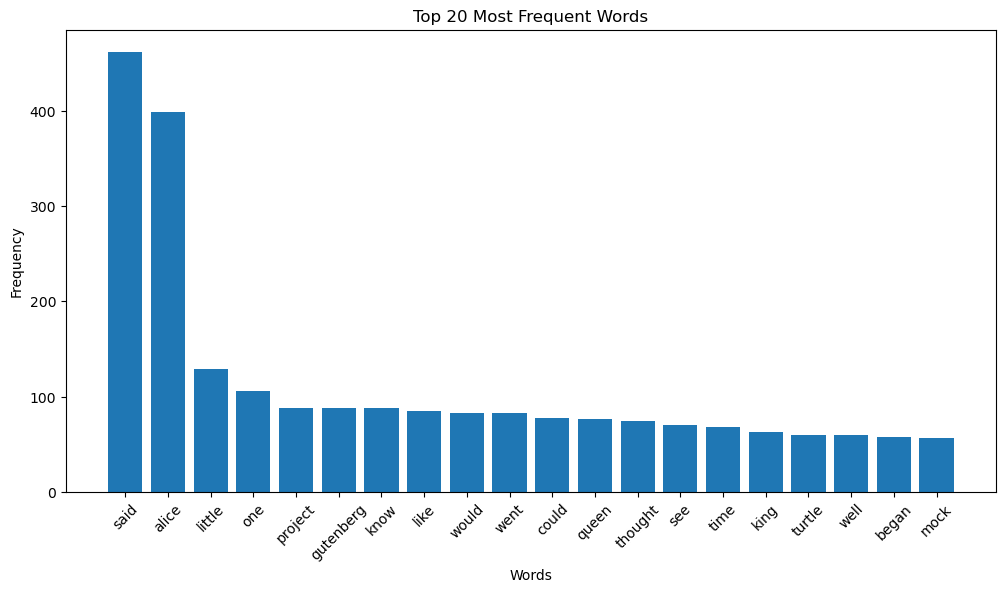

In [28]:
import matplotlib.pyplot as plt

top20 = word_freq.most_common(20)

words = [word for word, count in top20]
counts = [count for word, count in top20]

plt.figure(figsize=(12,6))
plt.bar(words, counts)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.savefig("top20_words.png")
plt.show()

In [29]:
from nltk.util import ngrams

# Create bigrams (pairs of consecutive words)
bigrams = list(ngrams(filtered_words, 2))

print(bigrams[:20])

[('project', 'gutenberg'), ('gutenberg', 'ebook'), ('ebook', 'alices'), ('alices', 'adventures'), ('adventures', 'wonderland'), ('wonderland', 'ebook'), ('ebook', 'use'), ('use', 'anyone'), ('anyone', 'anywhere'), ('anywhere', 'united'), ('united', 'states'), ('states', 'parts'), ('parts', 'world'), ('world', 'cost'), ('cost', 'almost'), ('almost', 'restrictions'), ('restrictions', 'whatsoever'), ('whatsoever', 'may'), ('may', 'copy'), ('copy', 'give')]


In [30]:
from collections import Counter

bigram_freq = Counter(bigrams)

print(bigram_freq.most_common(20))

[(('said', 'alice'), 123), (('project', 'gutenberg'), 88), (('mock', 'turtle'), 57), (('march', 'hare'), 31), (('said', 'king'), 29), (('thought', 'alice'), 26), (('white', 'rabbit'), 22), (('said', 'hatter'), 22), (('said', 'mock'), 20), (('said', 'caterpillar'), 18), (('said', 'gryphon'), 18), (('gutenberg', 'electronic'), 18), (('alice', 'said'), 17), (('electronic', 'works'), 16), (('united', 'states'), 15), (('said', 'duchess'), 15), (('said', 'cat'), 14), (('alice', 'thought'), 13), (('said', 'queen'), 13), (('gutenberg', 'literary'), 13)]


In [31]:
def autocomplete(word):
    predictions = {}

    # Find all words that follow the given word
    for (first, second), count in bigram_freq.items():
        if first == word:
            predictions[second] = count

    # Sort by frequency (highest first)
    sorted_predictions = sorted(
        predictions.items(),
        key=lambda x: x[1],
        reverse=True
    )

    # Return top 3 predictions
    return sorted_predictions[:3]

In [32]:
print(autocomplete("alice"))

[('said', 17), ('thought', 13), ('could', 11)]


In [33]:
print(autocomplete("alice"))

[('said', 17), ('thought', 13), ('could', 11)]


In [34]:
test_words = [
    "alice",
    "little",
    "queen",
    "king",
    "rabbit",
    "cat",
    "mouse",
    "mock",
    "gryphon",
    "hatter"
]

for word in test_words:
    print(f"\nInput: {word}")
    print("Top 3 Predictions:")
    
    predictions = autocomplete(word)

    if predictions:
        for prediction, count in predictions:
            print(f"{prediction} ({count})")
    else:
        print("No predictions found.")


Input: alice
Top 3 Predictions:
said (17)
thought (13)
could (11)

Input: little
Top 3 Predictions:
thing (8)
door (6)
golden (5)

Input: queen
Top 3 Predictions:
said (5)
hearts (4)
never (4)

Input: king
Top 3 Predictions:
said (11)
queen (5)
white (4)

Input: rabbit
Top 3 Predictions:
sends (2)
say (2)
came (2)

Input: cat
Top 3 Predictions:
said (4)
sitting (3)
vanished (2)

Input: mouse
Top 3 Predictions:
mouse (5)
know (2)
alice (2)

Input: mock
Top 3 Predictions:
turtle (57)

Input: gryphon
Top 3 Predictions:
went (4)
alice (3)
sat (2)

Input: hatter
Top 3 Predictions:
said (3)
went (3)
queen (2)


In [35]:
from spellchecker import SpellChecker

spell = SpellChecker()

In [36]:
misspelled_words = [
    "pythn",
    "langauge",
    "recieve",
    "teh",
    "acommodate",
    "definately",
    "enviroment",
    "goverment",
    "occured",
    "seperate",
    "writting",
    "adres",
    "becuase",
    "freind",
    "tommorow",
    "untill",
    "wierd",
    "beleive",
    "thier",
    "succesful"
]

In [37]:
print("Autocorrect Results")
print("-" * 50)

for word in misspelled_words:
    corrected = spell.correction(word)
    print(f"{word:15} ➜ {corrected}")

Autocorrect Results
--------------------------------------------------
pythn           ➜ python
langauge        ➜ language
recieve         ➜ receive
teh             ➜ the
acommodate      ➜ accommodate
definately      ➜ definitely
enviroment      ➜ environment
goverment       ➜ government
occured         ➜ occurred
seperate        ➜ separate
writting        ➜ writing
adres           ➜ dares
becuase         ➜ because
freind          ➜ friend
tommorow        ➜ tomorrow
untill          ➜ until
wierd           ➜ weird
beleive         ➜ believe
thier           ➜ their
succesful       ➜ successful


In [38]:
correct_words = [
    "python",
    "language",
    "receive",
    "the",
    "accommodate",
    "definitely",
    "environment",
    "government",
    "occurred",
    "separate",
    "writing",
    "address",
    "because",
    "friend",
    "tomorrow",
    "until",
    "weird",
    "believe",
    "their",
    "successful"
]

In [39]:
correct = 0

for wrong, actual in zip(misspelled_words, correct_words):
    prediction = spell.correction(wrong)

    if prediction == actual:
        correct += 1

accuracy = (correct / len(correct_words)) * 100

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 95.00%


In [40]:
tp = 0
fp = 0
fn = 0

for wrong, actual in zip(misspelled_words, correct_words):
    predicted = spell.correction(wrong)

    if predicted == actual:
        tp += 1
    else:
        fp += 1
        fn += 1

print("True Positives :", tp)
print("False Positives:", fp)
print("False Negatives:", fn)

True Positives : 19
False Positives: 1
False Negatives: 1


In [41]:
precision = tp / (tp + fp)
recall = tp / (tp + fn)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

Precision: 0.95
Recall: 0.95


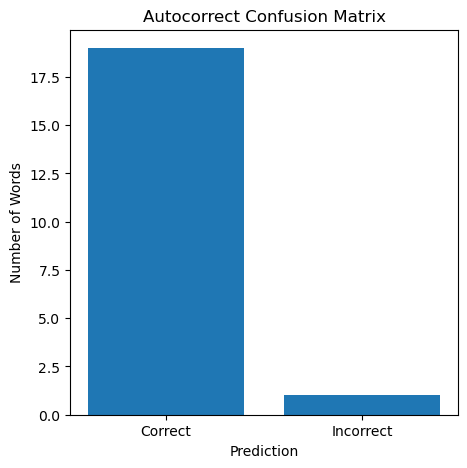

In [42]:
import matplotlib.pyplot as plt

# Values
correct = tp
incorrect = fp

labels = ["Correct", "Incorrect"]
values = [correct, incorrect]

plt.figure(figsize=(5,5))
plt.bar(labels, values)

plt.title("Autocorrect Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Number of Words")
plt.savefig("confusion_matrix.png")
plt.show()

In [43]:
from nltk.util import ngrams

# Create trigrams
trigrams = list(ngrams(filtered_words, 3))

print(trigrams[:10])

[('project', 'gutenberg', 'ebook'), ('gutenberg', 'ebook', 'alices'), ('ebook', 'alices', 'adventures'), ('alices', 'adventures', 'wonderland'), ('adventures', 'wonderland', 'ebook'), ('wonderland', 'ebook', 'use'), ('ebook', 'use', 'anyone'), ('use', 'anyone', 'anywhere'), ('anyone', 'anywhere', 'united'), ('anywhere', 'united', 'states')]


In [44]:
from collections import Counter

trigram_freq = Counter(trigrams)

print(trigram_freq.most_common(10))

[(('said', 'mock', 'turtle'), 20), (('project', 'gutenberg', 'electronic'), 18), (('project', 'gutenberg', 'literary'), 13), (('gutenberg', 'literary', 'archive'), 13), (('literary', 'archive', 'foundation'), 13), (('gutenberg', 'electronic', 'works'), 12), (('project', 'gutenberg', 'license'), 11), (('said', 'march', 'hare'), 10), (('full', 'project', 'gutenberg'), 7), (('poor', 'little', 'thing'), 6)]


In [45]:
def autocomplete_trigram(word1, word2):

    predictions = {}

    for (first, second, third), count in trigram_freq.items():
        if first == word1 and second == word2:
            predictions[third] = count

    sorted_predictions = sorted(
        predictions.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return sorted_predictions[:3]

In [46]:
print(autocomplete_trigram("mock", "turtle"))

[('said', 5), ('went', 3), ('replied', 3)]


# Algorithm Comparison

In this project, two autocomplete algorithms were implemented and compared: **Bigram** and **Trigram** models.

## Bigram vs. Trigram

| Feature | Bigram Model | Trigram Model |
|---------|--------------|---------------|
| Context Used | Uses one previous word | Uses two previous words |
| Prediction | Predicts the next word using one-word context | Predicts the next word using two-word context |
| Speed | Faster due to fewer computations | Slightly slower due to more computations |
| Accuracy | Good for simple predictions | More accurate because it considers additional context |
| Memory Usage | Lower | Higher |
| Complexity | Simple to implement | Slightly more complex |

### Experimental Results

The Bigram model predicted the next word using one previous word.

**Example:**

```python
autocomplete("alice")
```

Output:

```python
[('said', 17), ('thought', 13), ('could', 11)]
```

The Trigram model predicted the next word using two previous words.

**Example:**

```python
autocomplete_trigram("alice", "said")
```

Output:

```python
[('said', 5), ('went', 3), ('replied', 3)]
```

## Conclusion

The **Bigram model** is simple, fast, and requires less memory, making it suitable for basic autocomplete systems.

The **Trigram model** provides more context-aware predictions by considering the previous two words. Although it requires slightly more memory and computation, it generally produces more accurate autocomplete suggestions.

Therefore, the Trigram model performed better in terms of contextual prediction, while the Bigram model was more efficient and simpler to implement.

In [47]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


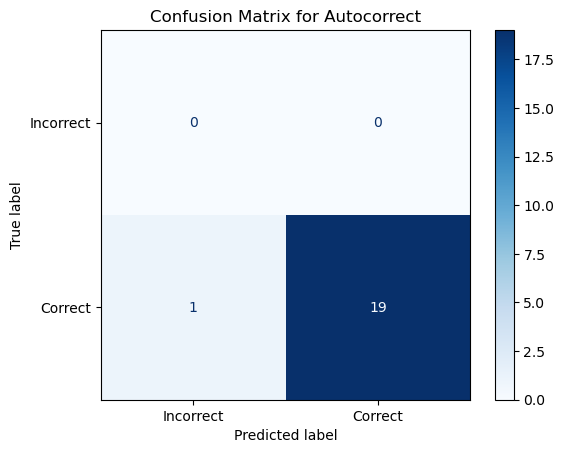

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# True labels (all words are expected to be corrected)
y_true = [1] * len(correct_words)

# Predicted labels
y_pred = []

for wrong, actual in zip(misspelled_words, correct_words):
    predicted = spell.correction(wrong)

    if predicted == actual:
        y_pred.append(1)
    else:
        y_pred.append(0)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Incorrect", "Correct"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix for Autocorrect")
plt.savefig("confusion_matrix.png")
plt.show()